In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import os
import torch.nn as nn
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
import random
import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 尽量让 CUDA 计算确定
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [3]:
class Cifar10Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        :param root_dir: 包含所有图片的目录路径
        :param transform: 对图片进行的预处理操作
        """
        self.root_dir = root_dir
        self.transform = transform
        # 获取该目录下所有的 jpg 图片路径
        # self.image_paths = glob.glob(os.path.join(root_dir, "*.jpg"))
        # print(len(self.image_paths))
        folder_paths = [
            name
            for name in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, name))
        ]
        folder_paths.sort()
        self.image_list = []
        self.label_list = []
        count = 0
        for folder in folder_paths:
            folder_path = root_dir + "/" + folder
            # print(folder)
            data_=glob.glob(os.path.join(folder_path, "*.png"))
            self.image_list.extend(data_)
            self.label_list.extend([count]* len(data_))
            count+=1

    def __len__(self):
        # 返回数据集的总大小
        return len(self.image_list)

    def __getitem__(self, idx):
        # 1. 根据索引获取图片路径
        img_path = self.image_list[idx]

        # 2. 读取图片并确保是RGB格式
        image = Image.open(img_path).convert("RGB")
        label = self.label_list[idx]

        # 4. 应用转换 (例如转为 Tensor, 改变大小等)
        if self.transform:
            image = self.transform(image)

        return image, label



In [ ]:
from torch.utils.data import Subset

g = torch.Generator()
g.manual_seed(42)

train_transform = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616],
        ),
        transforms.RandomErasing(p=0.20),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616],
        ),
    ]
)

test_path = "../../../../dataset/cifar10/test"
test_dataset = Cifar10Dataset(root_dir=test_path, transform=test_transform)
train_path = "../../../../dataset/cifar10/train"
train_dataset = Cifar10Dataset(root_dir=train_path, transform=train_transform)


batch_size = 256
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True, generator=g
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False, generator=g
)

In [5]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
        )

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.main(x)
        residual = self.shortcut(x)
        out = out + residual
        out = self.relu(out)
        return out

In [6]:
class Cifar10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.stage1 = nn.Sequential(
            BasicBlock(64, 64, stride=1),
            BasicBlock(64, 64, stride=1),
        )

        self.stage2 = nn.Sequential(
            BasicBlock(64, 128, stride=2),
            BasicBlock(128, 128, stride=1),
        )

        self.stage3 = nn.Sequential(
            BasicBlock(128, 256, stride=2),
            BasicBlock(256, 256, stride=1),
        )

        self.stage4 = nn.Sequential(
            BasicBlock(256, 512, stride=2),
            BasicBlock(512, 512, stride=1),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.stage1(x)  # [B, 64, 32, 32]
        x = self.stage2(x)  # [B, 128, 16, 16]
        x = self.stage3(x)  # [B, 256, 8, 8]
        x = self.stage4(x)  # [B, 512, 4, 4]

        x = self.classifier(x)
        return x

In [ ]:
model = Cifar10().to(device)
print(model)
num_epochs=150
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.SGD(
    model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4, nesterov=True
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=4e-5)
# print(model)

from torch.optim.swa_utils import AveragedModel

Cifar10(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): BasicBlock(
      (main): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Identity()
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (main): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runn

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device).long()

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计 loss
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # 统计 accuracy
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device).long()

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [9]:


train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_test_acc = 0.0
epoch = 0

In [ ]:
for _ in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    scheduler.step()

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "cifar-10_test.pt")

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} |"
        f"LR: {current_lr:.6f}"
    )
    epoch+=1

Epoch [1/150] Train Loss: 1.8673, Train Acc: 0.3610 | Test Loss: 2.3646, Test Acc: 0.1000 |LR: 0.049995
Epoch [2/150] Train Loss: 1.3894, Train Acc: 0.5434 | Test Loss: 2.4212, Test Acc: 0.1000 |LR: 0.049978
Epoch [3/150] Train Loss: 1.1753, Train Acc: 0.6368 | Test Loss: 2.4081, Test Acc: 0.1025 |LR: 0.049951
Epoch [4/150] Train Loss: 1.0336, Train Acc: 0.6998 | Test Loss: 2.3492, Test Acc: 0.1094 |LR: 0.049912
Epoch [5/150] Train Loss: 0.9255, Train Acc: 0.7464 | Test Loss: 2.2887, Test Acc: 0.1292 |LR: 0.049863
Epoch [6/150] Train Loss: 0.8483, Train Acc: 0.7778 | Test Loss: 2.2258, Test Acc: 0.2007 |LR: 0.049803
Epoch [7/150] Train Loss: 0.7910, Train Acc: 0.8014 | Test Loss: 2.1432, Test Acc: 0.2545 |LR: 0.049732
Epoch [8/150] Train Loss: 0.7478, Train Acc: 0.8174 | Test Loss: 2.0277, Test Acc: 0.3267 |LR: 0.049650
Epoch [9/150] Train Loss: 0.7078, Train Acc: 0.8346 | Test Loss: 1.8668, Test Acc: 0.3994 |LR: 0.049558
Epoch [10/150] Train Loss: 0.6787, Train Acc: 0.8460 | Test Loss

Best test acc: 0.9546


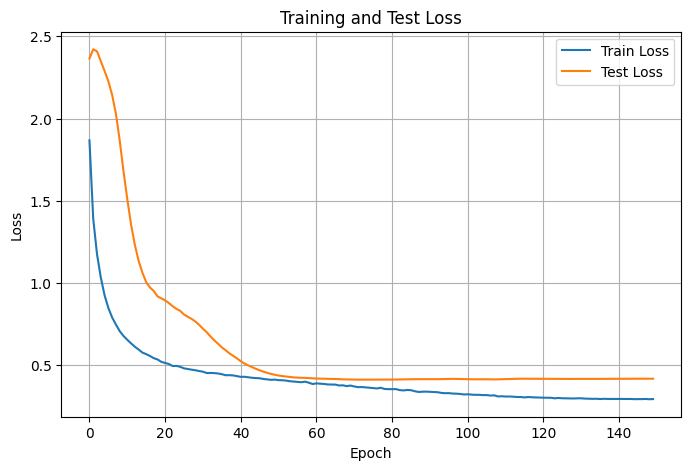

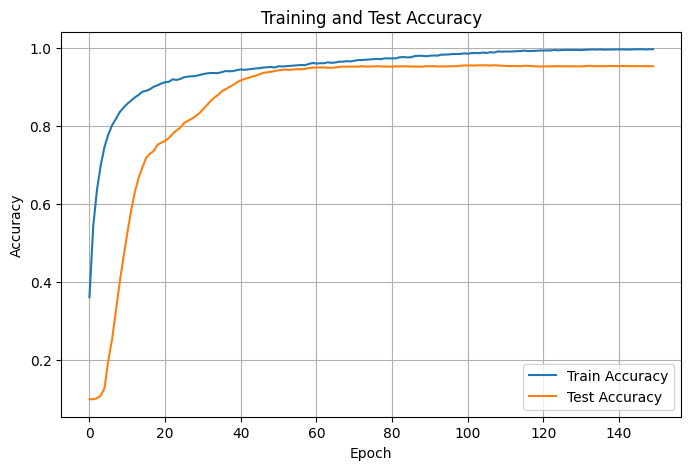

In [11]:
print(f"Best test acc: {best_test_acc:.4f}")
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()